# Born Displaced — Python Visualizations
**VIZ 5** Pictogram (explanatory) · **VIZ 6** Trajectory chart (creative) · **VIZ 7** White hat · **VIZ 8** Black hat

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.patheffects as pe
import seaborn as sns
import os
import base64
from io import BytesIO
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy import stats
import warnings
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import make_interp_spline

warnings.filterwarnings('ignore')

os.makedirs('plots/viz', exist_ok=True)
os.makedirs('plots/eda', exist_ok=True)
df = pd.read_csv('data/master_dataset.csv')
print(df.shape)

(3159, 17)


## VIZ 7 — White Hat
Scatter onesto: intervalli di confidenza UNICEF visibili, colore per gruppo di reddito, disclaimer su correlazione ≠ causalità.

Saved plots/viz/viz7_white_hat.html


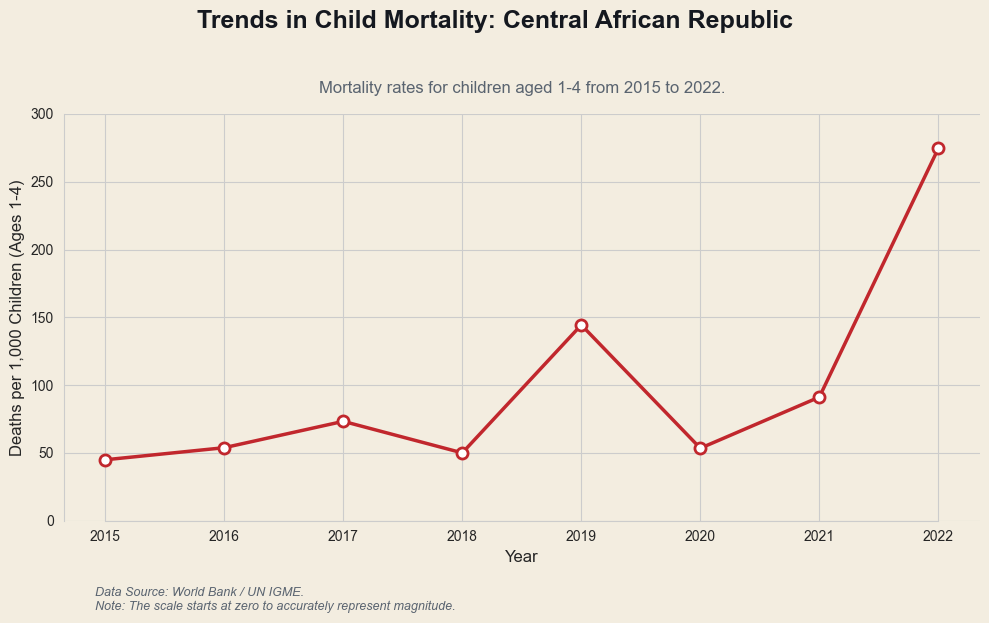

In [2]:
car_data = df[(df['country_name'] == 'Central African Republic') &
              (df['year'] >= 2015) & (df['year'] <= 2022)].sort_values('year')

plt.style.use('default')
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f3ede0')
ax.set_facecolor('#f3ede0')

ax.plot(car_data['year'], car_data['mortality_1t4'],
        color='#c1272d', linewidth=2.5, marker='o', markersize=8,
        markerfacecolor='white', markeredgewidth=2)

ax.set_ylim(0, 300)

plt.suptitle('Trends in Child Mortality: Central African Republic',
             fontsize=18, fontweight='bold', color='#14181f')
plt.title('Mortality rates for children aged 1-4 from 2015 to 2022.',
          fontsize=12, color='#5a6470', pad=15)
ax.set_ylabel('Deaths per 1,000 Children (Ages 1-4)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
plt.figtext(0.1, -0.02,
            "Data Source: World Bank / UN IGME.\n"
            "Note: The scale starts at zero to accurately represent magnitude.",
            ha="left", fontsize=9, color="#5a6470", style='italic')

sns.despine(trim=True)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

_buf = BytesIO()
fig.savefig(_buf, format='png', dpi=150, bbox_inches='tight', facecolor='#f3ede0')
_buf.seek(0)
_img = base64.b64encode(_buf.read()).decode()
with open('plots/viz/viz7_white_hat.html', 'w', encoding='utf-8') as _f:
    _f.write(f'<html><body style="margin:0;padding:0;background:#f3ede0">'
             f'<img src="data:image/png;base64,{_img}" style="width:100%;display:block">'
             f'</body></html>')
print('Saved plots/viz/viz7_white_hat.html')

plt.show()

## VIZ 8 — Black Hat
**Manipolazioni applicate:**
1. Asse Y troncato (parte da 3, non da 0) → differenze esagerate visivamente
2. Solo anni 2015–2022, solo paesi con >100k sfollati → cherry-pick
3. Fit polinomiale (grado 2) → trend visivamente più ripido del lineare
4. Nessun intervallo di confidenza
5. Tutti i marker in rosso → risposta emotiva
6. Titolo afferma causalità diretta
7. Annotazione suggerisce una stima causale precisa (inventata)

Saved plots/viz/viz8_black_hat.html


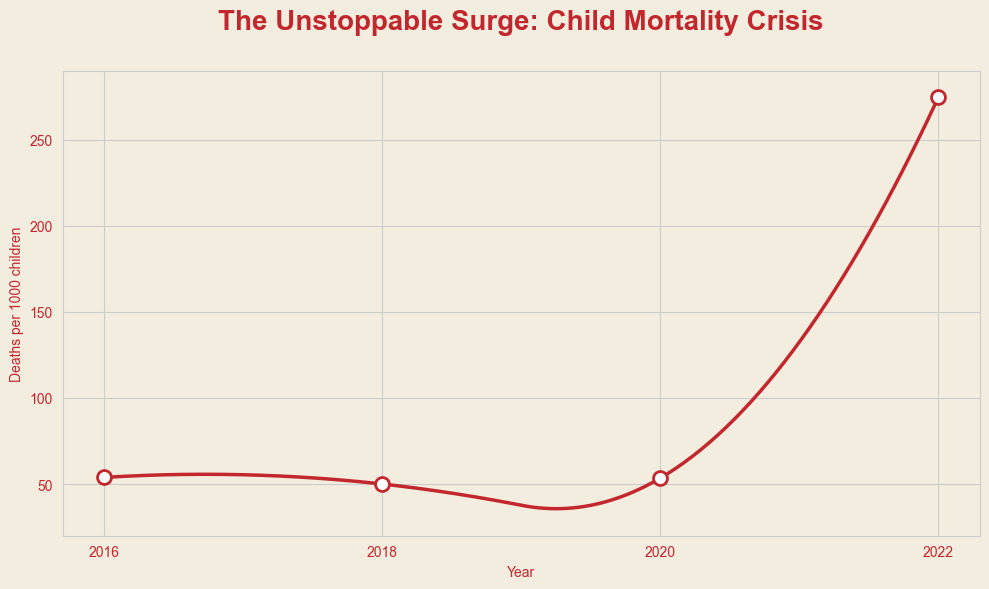

In [3]:
car_full = df[(df['country_name'] == 'Central African Republic') &
              (df['year'] >= 2015) & (df['year'] <= 2022)].sort_values('year')

track_years = [2016, 2018, 2020, 2022]
car_tracked = car_full[car_full['year'].isin(track_years)].sort_values('year')

x = car_tracked['year'].values
y = car_tracked['mortality_1t4'].values
x_smooth = np.linspace(x.min(), x.max(), 300)
spline = make_interp_spline(x, y, k=2)
y_smooth = spline(x_smooth)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f3ede0')
ax.set_facecolor('#f3ede0')

ax.plot(x_smooth, y_smooth, color='#c1272d', linewidth=2.5)
for i in range(1, 10):
    ax.plot(x_smooth, y_smooth, color='#c1272d', linewidth=i * 2, alpha=0.001)
ax.scatter(x, y, color='white', s=100, zorder=5, edgecolor='#c1272d', linewidth=2)

ax.set_xticks(track_years)
ax.set_ylim(20, 290)
ax.set_title('The Unstoppable Surge: Child Mortality Crisis',
             color='#c1272d', fontsize=20, pad=30, fontweight='bold')
ax.set_ylabel('Deaths per 1000 children', color='#c1272d')
ax.set_xlabel('Year', color='#c1272d')
ax.tick_params(axis='both', colors='#c1272d')

plt.tight_layout()

_buf = BytesIO()
fig.savefig(_buf, format='png', dpi=150, bbox_inches='tight', facecolor='#f3ede0')
_buf.seek(0)
_img = base64.b64encode(_buf.read()).decode()
with open('plots/viz/viz8_black_hat.html', 'w', encoding='utf-8') as _f:
    _f.write(f'<html><body style="margin:0;padding:0;background:#f3ede0">'
             f'<img src="data:image/png;base64,{_img}" style="width:100%;display:block">'
             f'</body></html>')
print('Saved plots/viz/viz8_black_hat.html')

plt.show()

## Output

In [4]:
import os

for root, dirs, files in os.walk('plots'):
    dirs.sort()
    level = root.replace('plots', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for fname in sorted(files):
        path = os.path.join(root, fname)
        size = os.path.getsize(path) // 1024
        print(f'{indent}  {fname}  ({size} KB)')

plots/
  eda/
    correlation_heatmap.png  (70 KB)
    gdp_mortality_displacement.png  (87 KB)
    missing_values.png  (30 KB)
    mortality_trend.png  (47 KB)
    scatter_displacement_mortality.png  (121 KB)
    top_displaced.png  (46 KB)
  tableau/
    treemap_crisis.html  (1 KB)
    viz_crisis.html  (3 KB)
    viz_maps.html  (2 KB)
  viz/
    viz5_explanatory_pictogram.html  (242 KB)
    viz6_creative_trajectory.html  (718 KB)
    viz7_white_hat.html  (128 KB)
    viz8_black_hat.html  (77 KB)


## VIZ 5 — Pictogram (English, matplotlib)

High displacement: 65 countries, avg mortality = 13.06
Low displacement:  65 countries, avg mortality = 2.10
Saved plots/viz/viz5_explanatory_pictogram.html


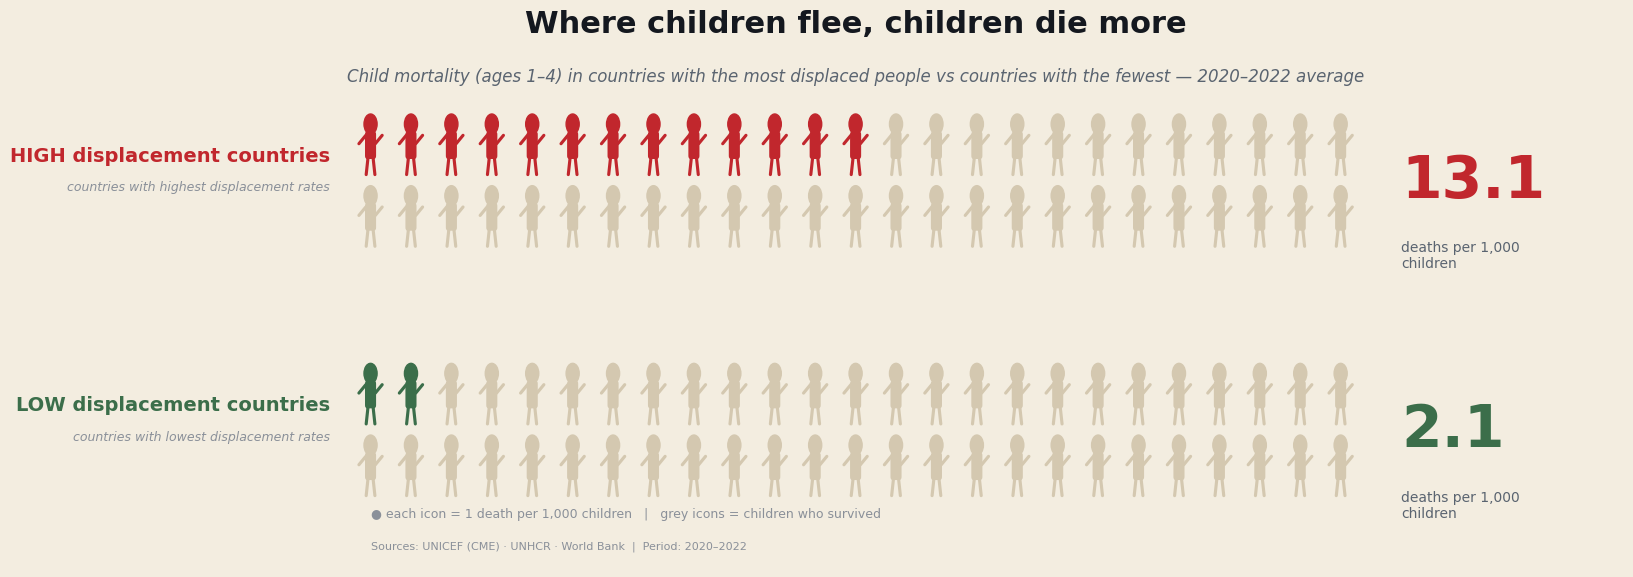

In [5]:
from matplotlib.patches import FancyBboxPatch

BG    = '#f3ede0'
INK   = '#14181f'
MUTED = '#5a6470'
DIM   = '#8a9099'
RED   = '#c1272d'
GREEN = '#3b6e4a'
EMPTY = '#d4c8b0'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

recent = df[df['year'].between(2020, 2022)]
country_avg = (
    recent.groupby('country_name')
    .agg(displaced=('total_displaced', 'mean'),
         mortality=('mortality_1t4', 'mean'))
    .dropna()
)

q_low, q_high = country_avg['displaced'].quantile([1/3, 2/3])
high_group = country_avg[country_avg['displaced'] >= q_high]
low_group  = country_avg[country_avg['displaced'] <= q_low]

mort_high = high_group['mortality'].mean()
mort_low  = low_group['mortality'].mean()

print(f'High displacement: {len(high_group)} countries, avg mortality = {mort_high:.2f}')
print(f'Low displacement:  {len(low_group)} countries, avg mortality = {mort_low:.2f}')


def child_icon(ax, x, y, size=1.0, color='#444'):
    s = size
    ax.add_patch(plt.Circle((x, y + 0.45 * s), 0.18 * s, color=color, zorder=2))
    ax.add_patch(FancyBboxPatch(
        (x - 0.13 * s, y - 0.15 * s), 0.26 * s, 0.45 * s,
        boxstyle='round,pad=0.02,rounding_size=0.05',
        linewidth=0, facecolor=color, zorder=1,
    ))
    ax.plot([x - 0.32 * s, x - 0.13 * s], [y + 0.1 * s, y + 0.25 * s],
            color=color, linewidth=2.5 * s, solid_capstyle='round', zorder=1)
    ax.plot([x + 0.13 * s, x + 0.32 * s], [y + 0.1 * s, y + 0.25 * s],
            color=color, linewidth=2.5 * s, solid_capstyle='round', zorder=1)
    ax.plot([x - 0.07 * s, x - 0.12 * s], [y - 0.15 * s, y - 0.45 * s],
            color=color, linewidth=2.5 * s, solid_capstyle='round', zorder=1)
    ax.plot([x + 0.07 * s, x + 0.12 * s], [y - 0.15 * s, y - 0.45 * s],
            color=color, linewidth=2.5 * s, solid_capstyle='round', zorder=1)


def draw_grid(ax, n_filled, n_total, x0, y0, color_filled,
              cols=25, color_empty=EMPTY, spacing_x=1.0, spacing_y=1.15):
    for i in range(n_total):
        col = i % cols
        row = i // cols
        x = x0 + col * spacing_x
        y = y0 - row * spacing_y
        color = color_filled if i < n_filled else color_empty
        child_icon(ax, x, y, size=0.9, color=color)


TOTAL_ICONS = 50
GRID_COLS   = 25
icons_high  = min(int(round(mort_high)), TOTAL_ICONS)
icons_low   = min(int(round(mort_low)),  TOTAL_ICONS)
HIGH_ROW_Y  = 4.5
LOW_ROW_Y   = 0.5

fig5, ax = plt.subplots(figsize=(16, 6), facecolor=BG)
ax.set_facecolor(BG)

fig5.suptitle('Where children flee, children die more',
              fontsize=22, fontweight='bold', y=0.98, color=INK)
fig5.text(0.5, 0.86,
          'Child mortality (ages 1–4) in countries with the most displaced people '
          'vs countries with the fewest — 2020–2022 average',
          ha='center', fontsize=12, color=MUTED, style='italic')

ax.text(-1.0, HIGH_ROW_Y - 0.1, 'HIGH displacement countries',
        fontsize=14, fontweight='bold', color=RED, ha='right', va='center')
ax.text(-1.0, HIGH_ROW_Y - 0.6, 'countries with highest displacement rates',
        fontsize=9, color=DIM, ha='right', va='center', style='italic')
draw_grid(ax, icons_high, TOTAL_ICONS, x0=0, y0=HIGH_ROW_Y, color_filled=RED, cols=GRID_COLS)
ax.text(GRID_COLS + 0.5, HIGH_ROW_Y - 0.5, f'{mort_high:.1f}',
        fontsize=42, fontweight='bold', color=RED, va='center')
ax.text(GRID_COLS + 0.5, HIGH_ROW_Y - 1.7, 'deaths per 1,000\nchildren',
        fontsize=10, color=MUTED, va='center')

ax.text(-1.0, LOW_ROW_Y - 0.1, 'LOW displacement countries',
        fontsize=14, fontweight='bold', color=GREEN, ha='right', va='center')
ax.text(-1.0, LOW_ROW_Y - 0.6, 'countries with lowest displacement rates',
        fontsize=9, color=DIM, ha='right', va='center', style='italic')
draw_grid(ax, icons_low, TOTAL_ICONS, x0=0, y0=LOW_ROW_Y, color_filled=GREEN, cols=GRID_COLS)
ax.text(GRID_COLS + 0.5, LOW_ROW_Y - 0.5, f'{mort_low:.1f}',
        fontsize=42, fontweight='bold', color=GREEN, va='center')
ax.text(GRID_COLS + 0.5, LOW_ROW_Y - 1.7, 'deaths per 1,000\nchildren',
        fontsize=10, color=MUTED, va='center')

ax.text(0, -1.4,
        '● each icon = 1 death per 1,000 children   |   grey icons = children who survived',
        fontsize=9, color=DIM)
ax.text(0, -1.9,
        'Sources: UNICEF (CME) · UNHCR · World Bank  |  Period: 2020–2022',
        fontsize=8, color=DIM)

ax.set_xlim(-7, GRID_COLS + 6)
ax.set_ylim(-2.2, 5.5)
ax.axis('off')
plt.subplots_adjust(top=0.85, bottom=0.05, left=0.02, right=0.98)

_buf = BytesIO()
fig5.savefig(_buf, format='png', dpi=150, bbox_inches='tight', facecolor=BG)
_buf.seek(0)
_img = base64.b64encode(_buf.read()).decode()
with open('plots/viz/viz5_explanatory_pictogram.html', 'w', encoding='utf-8') as _f:
    _f.write(f'<html><body style="margin:0;padding:0;background:{BG}">'
             f'<img src="data:image/png;base64,{_img}" style="width:100%;display:block">'
             f'</body></html>')
print('Saved plots/viz/viz5_explanatory_pictogram.html')

plt.show()

## VIZ 6 — Spiral (English, matplotlib)

Top 10 countries: ['Syrian Arab Republic', 'Colombia', 'Afghanistan', 'Democratic Republic of the Congo', 'Sudan', 'Somalia', 'South Sudan', 'Iraq', 'Yemen', 'Nigeria']
Saved plots/viz/viz6_creative_trajectory.html


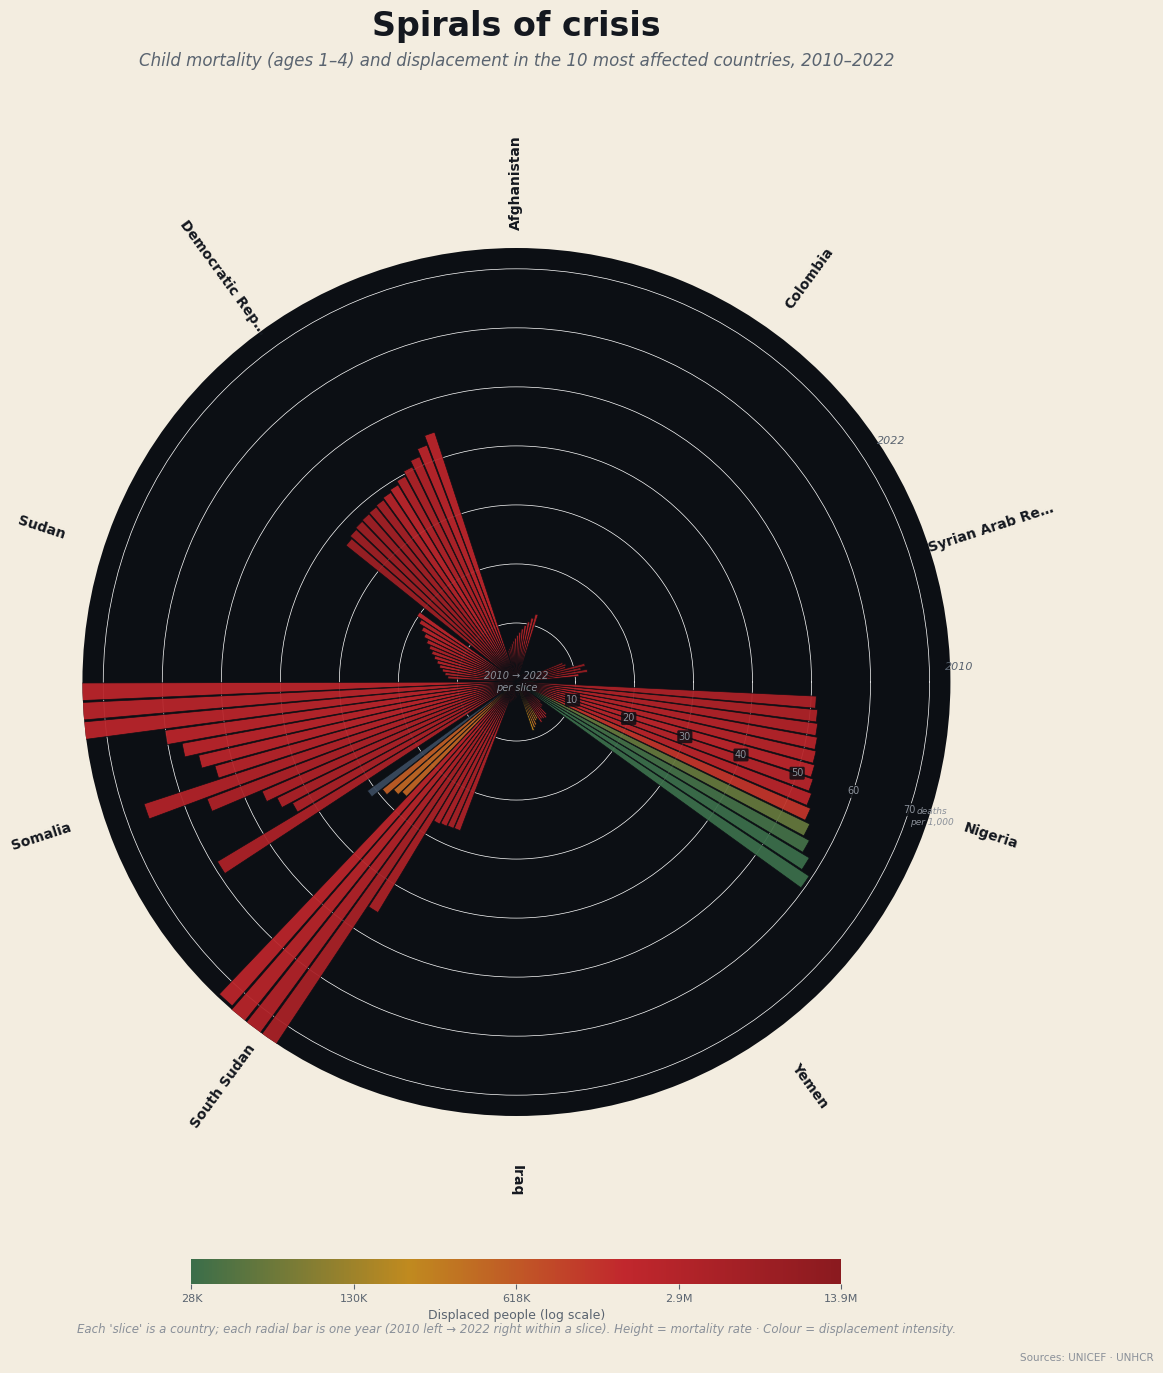

In [6]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

BG    = '#f3ede0'
PANEL = '#0c0f14'
INK   = '#14181f'
MUTED = '#5a6470'
DIM   = '#8a9099'

plt.rcParams.update({'font.family': 'DejaVu Sans'})

top10 = (
    df.groupby('country_name')['total_displaced']
    .mean().dropna().sort_values(ascending=False).head(10).index.tolist()
)
print(f'Top 10 countries: {top10}')

years = sorted(df['year'].unique())
n_years = len(years)
n_countries = len(top10)

mort_matrix = np.full((n_countries, n_years), np.nan)
disp_matrix = np.full((n_countries, n_years), np.nan)
for i, c in enumerate(top10):
    sub = df[df['country_name'] == c].set_index('year')
    for j, y in enumerate(years):
        if y in sub.index:
            mort_matrix[i, j] = sub.loc[y, 'mortality_1t4']
            disp_matrix[i, j] = sub.loc[y, 'total_displaced']

real_disp = disp_matrix[disp_matrix > 0]
disp_log = np.log10(np.where(disp_matrix > 0, disp_matrix, np.nan))
norm = Normalize(vmin=np.log10(np.nanmin(real_disp)), vmax=np.log10(np.nanmax(real_disp)))

cmap = LinearSegmentedColormap.from_list(
    'crisis', ['#3b6e4a', '#c08a1f', '#c1272d', '#8a1a1f']
)

fig6 = plt.figure(figsize=(13, 14), facecolor=BG)
ax = fig6.add_axes([0.1, 0.18, 0.8, 0.62], projection='polar')

slice_width = 2 * np.pi / n_countries
year_width = slice_width / (n_years + 1)
max_r = np.nanpercentile(mort_matrix, 95) * 1.05

for i, country in enumerate(top10):
    base_angle = i * slice_width
    for j, y in enumerate(years):
        r = mort_matrix[i, j]
        if np.isnan(r):
            continue
        theta = base_angle + (j + 0.5) * year_width
        d = disp_log[i, j]
        color = '#3a4a5e' if np.isnan(d) else cmap(norm(np.clip(d, norm.vmin, norm.vmax)))
        ax.bar(theta, r, width=year_width * 0.9, bottom=0.0,
               color=color, edgecolor=PANEL, linewidth=0.5, alpha=0.95)

    label_angle = base_angle + slice_width / 2
    label_r = max_r * 1.15
    deg = np.degrees(label_angle) % 360
    rotation = deg - 180 if 90 < deg < 270 else deg
    short = country if len(country) <= 16 else country[:14] + '…'
    ax.text(label_angle, label_r, short, ha='center', va='center', fontsize=10,
            fontweight='bold', rotation=rotation, rotation_mode='anchor', color=INK)

year_label_r = max_r * 1.02
ax.text(0.5 * year_width, year_label_r, '2010',
        ha='center', va='bottom', fontsize=8, color=MUTED, style='italic')
ax.text((n_years - 0.5) * year_width, year_label_r, '2022',
        ha='center', va='bottom', fontsize=8, color=MUTED, style='italic')
ax.text(0, 0, '2010 → 2022\nper slice', ha='center', va='center',
        fontsize=7, color=DIM, style='italic', zorder=5)

ax.set_ylim(0, max_r)
ring_ticks = np.arange(10, max_r, 10)
ax.set_yticks(ring_ticks)
ax.set_yticklabels([''] * len(ring_ticks))
ax.set_xticks([])
ax.grid(color=(1, 1, 1, 0.10), linewidth=0.5)
ax.spines['polar'].set_visible(False)
ax.set_facecolor(PANEL)

scale_angle = -slice_width / 2
for r in ring_ticks:
    ax.text(scale_angle, r, f'{int(r)}', ha='center', va='center', fontsize=7, color=DIM,
            bbox=dict(boxstyle='round,pad=0.15', facecolor=PANEL, edgecolor='none', alpha=0.85))
ax.text(scale_angle, ring_ticks[-1] + 4, 'deaths\nper 1,000',
        ha='center', va='center', fontsize=6.5, color=DIM, style='italic')

fig6.suptitle('Spirals of crisis', fontsize=24, fontweight='bold', y=0.97, color=INK)
fig6.text(0.5, 0.93,
          'Child mortality (ages 1–4) and displacement in the 10 most affected countries, 2010–2022',
          ha='center', fontsize=12, color=MUTED, style='italic')

cbar_ax = fig6.add_axes([0.25, 0.06, 0.5, 0.018])
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig6.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Displaced people (log scale)', fontsize=9, color=MUTED)


def human_readable(x):
    n = 10 ** x
    if n >= 1e6: return f'{n/1e6:.1f}M'
    if n >= 1e3: return f'{n/1e3:.0f}K'
    return f'{n:.0f}'


ticks_cbar = np.linspace(norm.vmin, norm.vmax, 5)
cbar.set_ticks(ticks_cbar)
cbar.set_ticklabels([human_readable(t) for t in ticks_cbar])
cbar.ax.tick_params(labelsize=8, colors=MUTED)
cbar.outline.set_visible(False)

fig6.text(0.5, 0.025,
          "Each 'slice' is a country; each radial bar is one year (2010 left → 2022 right within a slice). "
          "Height = mortality rate · Colour = displacement intensity.",
          ha='center', fontsize=8.5, color=DIM, style='italic')
fig6.text(0.99, 0.005, 'Sources: UNICEF · UNHCR', ha='right', fontsize=7.5, color=DIM)

_buf = BytesIO()
fig6.savefig(_buf, format='png', dpi=150, bbox_inches='tight', facecolor=BG)
_buf.seek(0)
_img = base64.b64encode(_buf.read()).decode()
with open('plots/viz/viz6_creative_trajectory.html', 'w', encoding='utf-8') as _f:
    _f.write(f'<html><body style="margin:0;padding:0;background:{BG}">'
             f'<img src="data:image/png;base64,{_img}" style="width:100%;display:block">'
             f'</body></html>')
print('Saved plots/viz/viz6_creative_trajectory.html')

plt.show()